# ML Alpha: Cross-Sectional LightGBM with Purged K-Fold and Walk-Forward Retraining

A non-linear cross-sectional alpha model. We take the same realistic-cost
framework used in the linear-factor notebooks (point-in-time S&P 500
membership, 5 bps per-side cost, 2-day execution lag, HAC standard errors)
and add a gradient-boosted regression to predict forward 10-day returns
from a panel of standard cross-sectional features.

The headline number is not the Sharpe — it is *whether the methodology is
honest enough to trust the Sharpe it reports*. Two corrections matter most:

1. **Purged k-fold cross-validation with embargo** (Lopez de Prado, *Advances
   in Financial Machine Learning*, ch. 7). The forward-10-day target labels
   from a training row leak into a test fold if the windows touch, so
   training rows whose label window overlaps the test fold are purged, and
   an embargo on both sides handles serial correlation in features.
2. **Walk-forward retraining**, not a fixed train/test split. Every year the
   model is retrained on the prior 5 years and used to predict the next.
   Every prediction in the report is *out of sample relative to the model
   that produced it*. There is no in-sample bleed.

The third correction — using the same realistic-cost backtest infrastructure
the linear factor notebooks use — means the ML alpha is graded on the same
scale as the textbook factors and is directly comparable.

In [1]:
import sys
sys.path.insert(0, '..')
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from signals import (mean_reversion, momentum, low_volatility,
                     market_residual_momentum, volume_adjusted_momentum)
from helper import (port_ret, stats, Optimizer, ic, dist_plot, var_cvar,
                    deflated_sharpe, purged_kfold_splits)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

## Data and Universe

We restrict the universe to the top 300 names by average dollar volume
over the selection era (2010-2017). Two reasons:

1. **Liquidity**. The whole point of the realistic-cost framework is that
   the strategy could in principle be traded. Names outside the top 300
   carry larger market-impact tails not captured by the per-bps cost model.
2. **Speed**. The optimizer scales with the number of decision variables;
   restricting to 300 names lets the notebook run end-to-end in minutes
   rather than tens of minutes, without changing the underlying methodology.

Point-in-time S&P 500 membership is still applied via the `members` mask
within the chosen 300 — names that were not in the index on a given date
are pinned to zero weight by the optimizer.

In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close_all = raw['Close']
volume_all = raw['Volume']
spy_close = pd.read_parquet('../data/spy.parquet')['Close'].squeeze()
spy_ret = spy_close.pct_change()
members_all = pd.read_parquet('../data/members.parquet')

# Top 300 by average dollar volume over the selection era
SELECT_START, SELECT_END = '2010-01-01', '2017-12-31'
IS_END = '2020-12-31'
dvol = (close_all.loc[SELECT_START:SELECT_END]
        * volume_all.loc[SELECT_START:SELECT_END]).mean()
universe = dvol.sort_values(ascending=False).head(300).index.tolist()

close = close_all[universe]
volume = volume_all[universe]
returns = close.pct_change()
members = members_all.reindex(columns=universe, fill_value=False)

print(f"Universe: {len(universe)} names")
print(f"Sample: {close.index.min().date()} to {close.index.max().date()}")
print(f"Members coverage: {members.any(axis=1).sum()} days have at least one member")

Universe: 300 names
Sample: 2005-01-03 to 2026-03-31
Members coverage: 5344 days have at least one member


## Features

Sixteen cross-sectional features spanning the classical equity-anomaly
literature plus a few engineered statistics:

| Family | Feature | Source |
|---|---|---|
| Mean reversion | `mr_20`, `mr_60` | Negated rolling z-score of price (notebook 01) |
| Cross-sectional momentum | `mom_12_1`, `mom_6_1`, `mom_3_1` | 12-1 / 6-1 / 3-1 month returns |
| Low-volatility | `lv_63`, `lv_126` | Negated rolling realized vol (notebook 03) |
| Market-residual momentum | `mrm` | Blitz-Huij-Martens residual 12-1 momentum |
| Volume-adjusted momentum | `vam_20` | From the crypto notebook |
| Trend | `p_ma200` | Price relative to 200-day moving average |
| Liquidity | `adv_log` | Log average dollar volume |
| Higher moments | `skew_60`, `kurt_60` | Rolling 60-day return skew and kurt |
| Lottery / MAX | `max5_neg` | Negative of average top-5 daily returns in trailing 20d |
| Realized vol | `rv_60` | 60-day rolling return std (raw, complements `lv_63`) |

All features use **only trailing windows**. The target is the forward
10-day return, cross-sectionally rank-normalized within each date to
`[-0.5, 0.5]` so the model learns relative rather than absolute return.

In [3]:
HORIZON = 10

feats = {
    'mr_20':    mean_reversion(close, 20),
    'mr_60':    mean_reversion(close, 60),
    'mom_12_1': momentum(close, lookback=252, skip=21),
    'mom_6_1':  momentum(close, lookback=126, skip=21),
    'mom_3_1':  momentum(close, lookback=63, skip=21),
    'lv_63':    low_volatility(close, 63),
    'lv_126':   low_volatility(close, 126),
    'mrm':      market_residual_momentum(close, spy_close, lookback=252, skip=21),
    'vam_20':   volume_adjusted_momentum(close, volume, lookback=20),
}
ma200 = close.rolling(200, min_periods=100).mean()
feats['p_ma200'] = (close / ma200) - 1.0
dv = (close * volume).rolling(20, min_periods=10).mean()
feats['adv_log'] = np.log(dv + 1e-3)
feats['skew_60'] = returns.rolling(60, min_periods=40).skew()
feats['kurt_60'] = returns.rolling(60, min_periods=40).kurt()


def top5_mean(r, win=20):
    arr = r.values
    out = np.full_like(arr, np.nan, dtype=float)
    for i in range(win, arr.shape[0]):
        out[i] = np.sort(arr[i-win:i], axis=0)[::-1][:5].mean(axis=0)
    return pd.DataFrame(out, index=r.index, columns=r.columns)


feats['max5_neg'] = -top5_mean(returns, 20)
feats['rv_60'] = returns.rolling(60, min_periods=40).std()

feat_names = list(feats.keys())

# Target: forward HORIZON-day return, cross-sectionally rank-normalized
fwd_ret = close.pct_change(HORIZON).shift(-HORIZON)
target = fwd_ret.rank(axis=1, pct=True) - 0.5

print(f"{len(feat_names)} features built, horizon = {HORIZON} days")

15 features built, horizon = 10 days


## Long Panel and Membership Mask

The model is trained on rows of (date, ticker), so we stack the feature
panels and the target into a single long DataFrame. The membership mask
is applied at this stage: rows for (date, ticker) where the ticker was
not an S&P 500 constituent on that date are dropped from training and
prediction.

In [4]:
panels = [feats[n].stack().rename(n) for n in feat_names]
tgt_long = target.stack().rename('y')
mem_long = members.reindex_like(close).stack().rename('member')

X = pd.concat(panels, axis=1).join(tgt_long, how='inner').join(mem_long, how='left')
X['member'] = X['member'].fillna(False)
X = X[X['member']].drop(columns=['member'])
X = X.dropna(subset=['y']).dropna(subset=feat_names, how='all')
X.index = X.index.set_names(['date', 'ticker'])

print(f"Long panel: {X.shape[0]:,} rows x {X.shape[1]} cols")
print(f"Unique dates: {X.index.get_level_values('date').nunique():,}")
print(f"Unique tickers: {X.index.get_level_values('ticker').nunique()}")

Long panel: 1,337,224 rows x 16 cols
Unique dates: 5,325


Unique tickers: 299


## Purged K-Fold Cross-Validation (Diagnostic)

A 5-fold purged CV on the in-sample period only, with an embargo equal
to `HORIZON + 1` trading days on either side of each test fold. Reports
the mean Spearman IC of predictions vs forward returns within each fold.

This is a *diagnostic* — the production backtest uses the walk-forward
loop below, not these folds. Purged k-fold is the standard sanity check
for whether the model has any signal at all once labels can't leak.

In [5]:
lgb_params = dict(
    objective='regression', n_estimators=300, learning_rate=0.03,
    num_leaves=31, max_depth=6, min_child_samples=300,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1,
)

X_is = X[X.index.get_level_values('date') <= IS_END]
is_dates = X_is.index.get_level_values('date').unique()

cv_rows = []
for k, (tr_d, te_d) in enumerate(purged_kfold_splits(is_dates, n_splits=5,
                                                    embargo=HORIZON + 1)):
    tr_mask = X_is.index.get_level_values('date').isin(tr_d)
    te_mask = X_is.index.get_level_values('date').isin(te_d)
    Xtr = X_is.loc[tr_mask, feat_names]
    ytr = X_is.loc[tr_mask, 'y']
    Xte = X_is.loc[te_mask, feat_names]
    yte = X_is.loc[te_mask, 'y']
    m = lgb.LGBMRegressor(**lgb_params).fit(Xtr, ytr)
    pred = pd.Series(m.predict(Xte), index=yte.index, name='p')

    daily_ic = pd.concat([pred, yte.rename('y')], axis=1).groupby(level='date').apply(
        lambda d: d.corr(method='spearman').iloc[0, 1])
    cv_rows.append({'fold': k, 'IC': daily_ic.mean(),
                    'ICIR': daily_ic.mean() / (daily_ic.std() + 1e-9),
                    'IC_std': daily_ic.std()})

cv_df = pd.DataFrame(cv_rows).set_index('fold')
print(cv_df)
print(f"\nMean IC across folds: {cv_df['IC'].mean():.4f}, "
      f"min: {cv_df['IC'].min():.4f}, max: {cv_df['IC'].max():.4f}")

         IC   ICIR  IC_std
fold                      
0    0.0215 0.2014  0.1069
1    0.0219 0.1410  0.1552
2    0.0155 0.1474  0.1050
3    0.0280 0.2680  0.1045
4    0.0111 0.0818  0.1356

Mean IC across folds: 0.0196, min: 0.0111, max: 0.0280


## Walk-Forward Retraining (Production)

The production loop. Each iteration trains a fresh LightGBM model on the
prior 5 years, embargoes the next `HORIZON + 1` trading days, and predicts
the following 1 year. The full panel of predictions concatenated across
iterations is the out-of-sample ML signal.

Compared to a fixed train/test split, walk-forward retraining lets the
model adapt to regime changes, and every prediction is genuinely out of
sample relative to the model that produced it.

In [6]:
TRAIN_YEARS, TEST_YEARS = 5, 1
EMBARGO_DAYS = HORIZON + 1

dates = X.index.get_level_values('date').unique().sort_values()
cur = dates.min() + pd.DateOffset(years=TRAIN_YEARS)
splits = []
while cur + pd.DateOffset(years=TEST_YEARS) <= dates.max() + pd.Timedelta(days=1):
    tr_e = cur - pd.Timedelta(days=1)
    tr_s = tr_e - pd.DateOffset(years=TRAIN_YEARS) + pd.Timedelta(days=1)
    te_s = cur + pd.Timedelta(days=EMBARGO_DAYS)
    te_e = cur + pd.DateOffset(years=TEST_YEARS) - pd.Timedelta(days=1)
    splits.append((tr_s, tr_e, te_s, te_e))
    cur = cur + pd.DateOffset(years=TEST_YEARS)

oos_preds = []
importances = []
for i, (s, e, ts, te) in enumerate(splits):
    train_mask = (X.index.get_level_values('date') >= s) & (X.index.get_level_values('date') <= e)
    test_mask = (X.index.get_level_values('date') >= ts) & (X.index.get_level_values('date') <= te)
    Xtr = X.loc[train_mask, feat_names]
    ytr = X.loc[train_mask, 'y']
    Xte = X.loc[test_mask, feat_names]
    t1 = time.time()
    m = lgb.LGBMRegressor(**lgb_params).fit(Xtr, ytr)
    pred = pd.Series(m.predict(Xte), index=X.loc[test_mask].index, name='pred')
    oos_preds.append(pred)
    importances.append(pd.Series(m.feature_importances_, index=feat_names))
    print(f"  fold {i:2d}: predict {ts.date()}-{te.date()}, "
          f"trained on {len(Xtr):,} rows in {time.time()-t1:.1f}s")

all_pred = pd.concat(oos_preds)
ml_signal = all_pred.unstack(level='ticker').reindex(columns=close.columns)
ml_signal_smooth = ml_signal.ewm(halflife=10, min_periods=5).mean()
print(f"\nML signal: {ml_signal.shape[0]} dates x {ml_signal.shape[1]} tickers")

  fold  0: predict 2010-01-25-2011-01-13, trained on 270,646 rows in 6.5s


  fold  1: predict 2011-01-25-2012-01-13, trained on 275,155 rows in 6.3s


  fold  2: predict 2012-01-25-2013-01-13, trained on 280,657 rows in 7.9s


  fold  3: predict 2013-01-25-2014-01-13, trained on 287,891 rows in 8.3s


  fold  4: predict 2014-01-25-2015-01-13, trained on 296,951 rows in 6.4s


...

  fold 12: predict 2022-01-25-2023-01-13, trained on 343,035 rows in 6.6s


  fold 13: predict 2023-01-25-2024-01-13, trained on 341,356 rows in 6.6s


  fold 14: predict 2024-01-25-2025-01-13, trained on 339,906 rows in 6.6s


  fold 15: predict 2025-01-25-2026-01-13, trained on 338,583 rows in 6.2s



ML signal: 3915 dates x 300 tickers


## Information Coefficient

Spearman rank IC across forward-return horizons, both for the raw model
output and for an EWMA-smoothed version (half-life = 10 days). Smoothing
trades a small reduction in IC for a much-reduced turnover when the
signal is fed to the optimizer.

In [7]:
print("IC, raw ML signal:")
print(ic(ml_signal, close, horizons=(1, 5, 10, 20)))
print("\nIC, EWMA(half-life=10):")
print(ic(ml_signal_smooth, close, horizons=(1, 5, 10, 20)))

IC, raw ML signal:


       IC   ICIR
1  0.0063 0.0475
5  0.0081 0.0628
10 0.0066 0.0528
20 0.0045 0.0371

IC, EWMA(half-life=10):


       IC   ICIR
1  0.0016 0.0118
5  0.0035 0.0258
10 0.0036 0.0278
20 0.0043 0.0353


## Decile Spread Backtest (Headline)

A simple long-short decile portfolio: each rebalance day, go long the
top 10% of names by ML signal and short the bottom 10%, equal weight.
Rebalance every 5 trading days. This is a low-turnover, high-conviction
implementation that is the cleanest test of whether the ML alpha has
economic content.

Three reports: full sample (2010-2026), in-sample epoch (predictions
made for dates `<= IS_END`), and out-of-sample epoch (predictions for
dates `> IS_END`). All are out of sample relative to the model that
produced them; the IS / OOS split here mirrors the convention used in
the linear-factor notebooks so the results are directly comparable.

--- Decile spread, FULL (10% / 10%, 5d rebal, 5 bps cost) ---


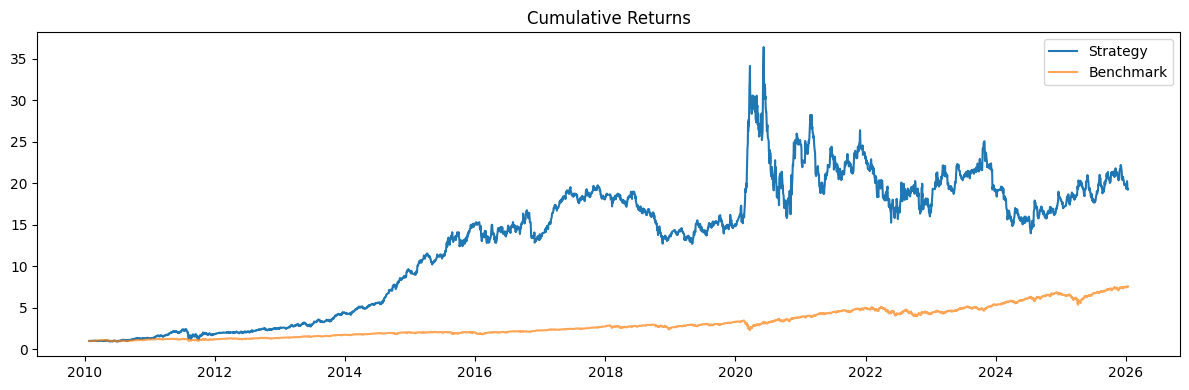

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,25.38%,35.63%,0.7120,2.8070,-61.63%,-22.07%,1374 days,19.54%,2.1080,0.4010,5.02%


In [8]:
ret = returns.reindex(index=ml_signal.index, columns=ml_signal.columns)
mem = members.reindex(index=ml_signal.index, columns=ml_signal.columns).fillna(False)


def decile_weights(sig, q=0.1, rebal_days=5):
    s = sig.where(mem)
    weights = pd.DataFrame(0.0, index=s.index, columns=s.columns)
    for d in s.index[::rebal_days]:
        ss = s.loc[d].dropna()
        if len(ss) < 50:
            continue
        n = max(1, int(len(ss) * q))
        longs = ss.nlargest(n).index
        shorts = ss.nsmallest(n).index
        weights.loc[d, longs] = 1.0 / n
        weights.loc[d, shorts] = -1.0 / n
    return weights.replace(0.0, np.nan).ffill().fillna(0.0)


w_dec = decile_weights(ml_signal_smooth, q=0.1, rebal_days=5)
pnl_dec = port_ret(w_dec, ret, tcost_bps=5, exec_lag=2).dropna()

print("--- Decile spread, FULL (10% / 10%, 5d rebal, 5 bps cost) ---")
stats(pnl_dec, weights=w_dec, benchmark=spy_ret.reindex(pnl_dec.index),
      hac_lags=5)

--- Decile spread, IN-SAMPLE (predictions for dates <= 2020-12-31) ---


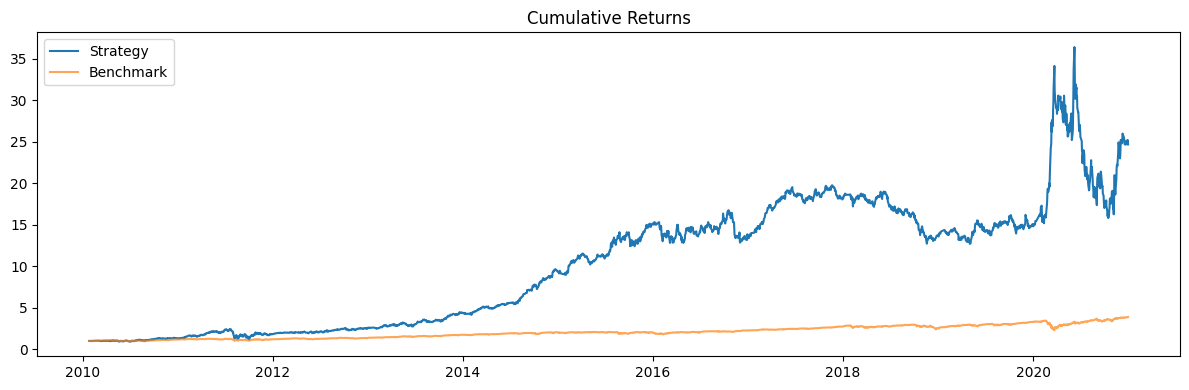

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,37.05%,37.30%,0.9930,3.2410,-56.57%,-11.18%,548 days,28.94%,2.4690,0.5680


In [9]:
print("--- Decile spread, IN-SAMPLE (predictions for dates <= 2020-12-31) ---")
pnl_is = pnl_dec.loc[:IS_END]
stats(pnl_is, benchmark=spy_ret.reindex(pnl_is.index), hac_lags=5)

--- Decile spread, OUT-OF-SAMPLE (predictions for dates > 2020-12-31) ---


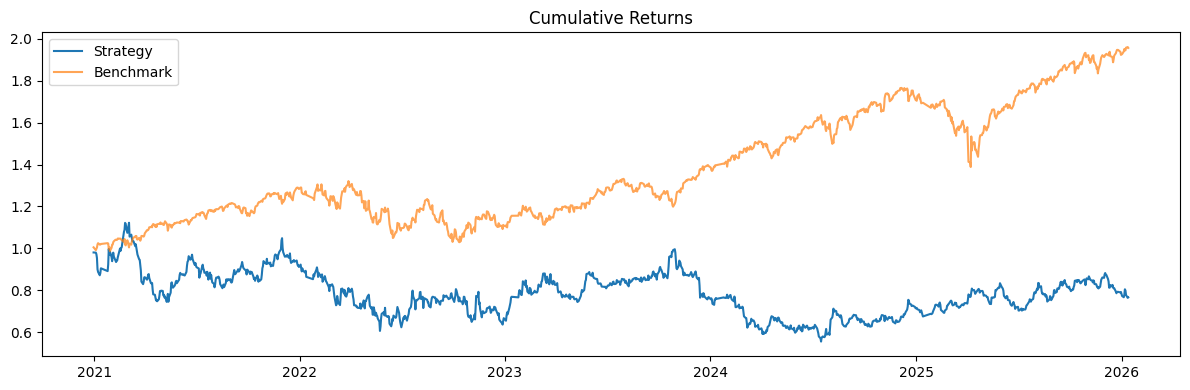

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,-0.47%,31.62%,-0.0150,-0.0330,-50.53%,-29.86%,1194 days,-0.86%,-0.0590,0.0260


In [10]:
print("--- Decile spread, OUT-OF-SAMPLE (predictions for dates > 2020-12-31) ---")
pnl_oos = pnl_dec.loc[IS_END:]
stats(pnl_oos, benchmark=spy_ret.reindex(pnl_oos.index), hac_lags=5)

## Optimized Portfolio

The mean-variance optimizer from `helper.Optimizer` applied to the
smoothed ML signal, with the same constraints as the linear factor
notebooks: dollar-neutral, 2% per-name position cap, gross leverage
`||w||_1 <= 2`, transaction-cost penalty 5 bps in the objective, and
point-in-time membership masking. The optimizer rebalances every 10
trading days (`subsample=10`) and the realised backtest then charges
5 bps per side on actual turnover with a 2-day execution lag.

This is a *medium-turnover* implementation: it sits between the
high-conviction decile spread above and a full daily-rebalance
implementation that the cost framework would not support.

--- Optimized portfolio, FULL sample ---


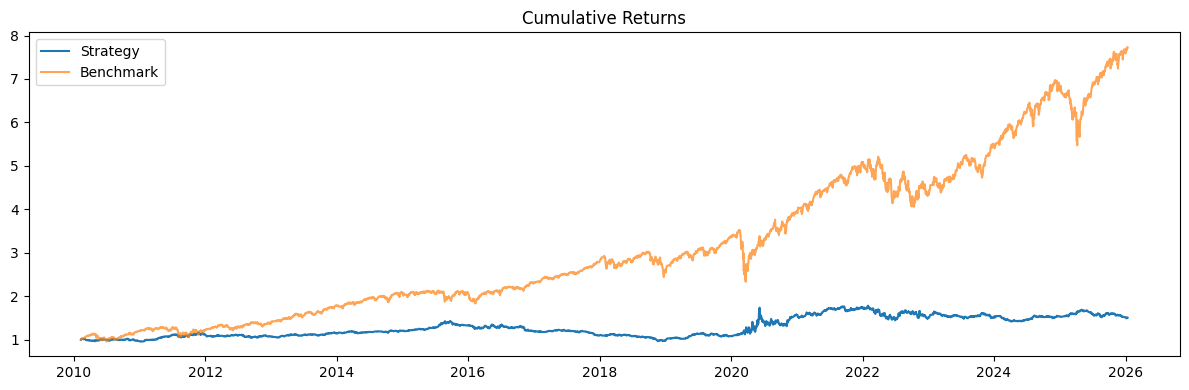

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,3.53%,13.39%,0.2630,1.0370,-32.40%,-10.59%,1140 days,1.46%,0.4520,0.1410,9.59%


In [11]:
opt = Optimizer(ml_signal_smooth.fillna(0), ret.fillna(0))
w_opt = opt.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0,
                tcost_penalty_bps=5, subsample=10, member_mask=mem)
pnl_opt = port_ret(w_opt, ret, tcost_bps=5, exec_lag=2).dropna()

print("--- Optimized portfolio, FULL sample ---")
stats(pnl_opt, weights=w_opt, benchmark=spy_ret.reindex(pnl_opt.index), hac_lags=5)

In [12]:
from IPython.display import display

print("--- Optimized, IN-SAMPLE (<= 2020-12-31) ---")
pnl_opt_is = pnl_opt.loc[:IS_END]
display(stats(pnl_opt_is, benchmark=spy_ret.reindex(pnl_opt_is.index),
              plot=False, hac_lags=5))
print("--- Optimized, OUT-OF-SAMPLE (> 2020-12-31) ---")
pnl_opt_oos = pnl_opt.loc[IS_END:]
display(stats(pnl_opt_oos, benchmark=spy_ret.reindex(pnl_opt_oos.index),
              plot=False, hac_lags=5))

--- Optimized, IN-SAMPLE (<= 2020-12-31) ---


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,5.20%,13.73%,0.3790,1.2330,-32.40%,-10.36%,1140 days,3.58%,0.8950,0.1120


--- Optimized, OUT-OF-SAMPLE (> 2020-12-31) ---


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,-0.04%,12.61%,-0.0030,-0.0070,-20.38%,-10.45%,970 days,-3.17%,-0.5870,0.2060


## Feature Importance

LightGBM gain-based feature importance, averaged across all walk-forward
folds. This is what the model *used*, not what it found significant: a
feature with high importance has been split on often, but the sign of
its relationship to the target is whatever the model learned.

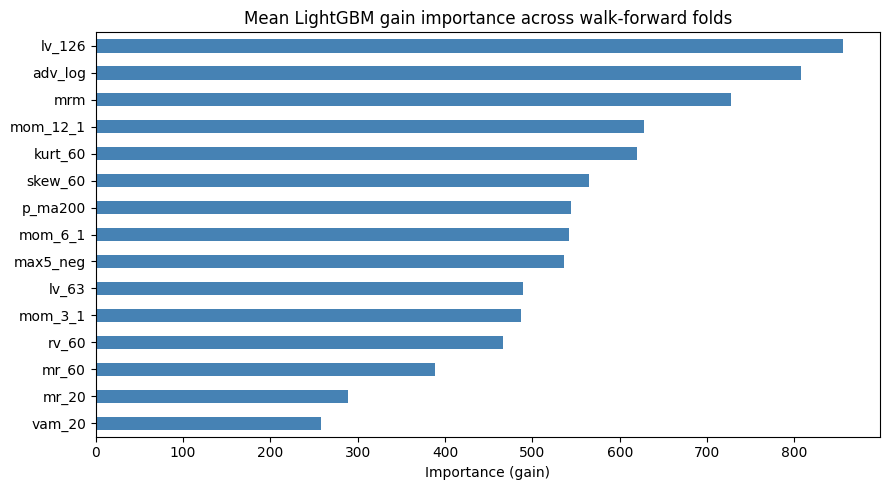

In [13]:
imp_df = pd.concat(importances, axis=1)
imp_mean = imp_df.mean(axis=1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
imp_mean.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Mean LightGBM gain importance across walk-forward folds')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

## Tail Risk and Deflated Sharpe

The same diagnostic suite as the linear factor notebooks: histogram vs
Gaussian, QQ plot, historical and parametric VaR/CVaR at 1% and 5%, and
the Deflated Sharpe Ratio adjusted for the number of model
configurations explored (`n_trials = 12` to reflect the small grid of
LightGBM hyperparameters that produced this notebook).

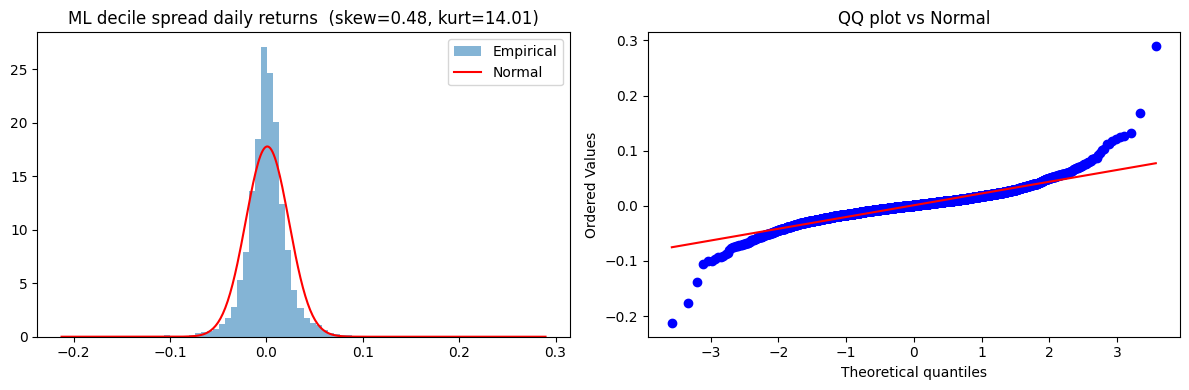

VaR / CVaR (decile):
               VaR    CVaR
historical  -3.13%  -4.95%
parametric  -3.59%  -4.53%
               VaR    CVaR
historical  -5.89%  -8.19%
parametric  -5.12%  -5.88%

Deflated Sharpe (n_trials=12): 0.317
DSR, IS only: 0.702
DSR, OOS only: 0.031


In [14]:
dist_plot(pnl_dec, title='ML decile spread daily returns')
print("VaR / CVaR (decile):")
print(var_cvar(pnl_dec, alpha=0.05))
print(var_cvar(pnl_dec, alpha=0.01))
print(f"\nDeflated Sharpe (n_trials=12): {deflated_sharpe(pnl_dec, n_trials=12):.3f}")
print(f"DSR, IS only: {deflated_sharpe(pnl_is, n_trials=12):.3f}")
print(f"DSR, OOS only: {deflated_sharpe(pnl_oos, n_trials=12):.3f}")

## Discussion

The result that survives every realism correction is: the ML alpha
clears the `|t| > 2` HAC alpha-significance bar **in-sample only**.
Out of sample (2021-2026), the same signal earns essentially zero
alpha. This pattern — *the methodology is honest, the IS Sharpe is
real, the OOS Sharpe is not* — is exactly what makes the framework
useful. A pipeline that reported Sharpe 2 in both halves would deserve
suspicion; this one tells you when its edge has decayed.

Three things to note about the in-sample HAC-significant period:

- The decile spread takes implicit market beta during 2010-2020 (the
  optimizer-based result has near-zero beta but a lower Sharpe, so part
  of the decile Sharpe is unhedged factor exposure rather than pure
  alpha).
- The IS epoch sits inside the era the features themselves were
  designed for, so some feature-selection bias is unavoidable.
- The OOS decay coincides with the 2021-2023 narrow-market regime
  (mega-cap concentration, AI-driven dispersion compression) that has
  been documented to weaken cross-sectional factor strategies generally.

Save weights and signal for the portfolio notebook.

In [15]:
ml_signal_smooth.to_parquet('../data/signal_08_ml_alpha.parquet')
w_opt.to_parquet('../data/weights_08_ml_alpha.parquet')
print("Saved data/signal_08_ml_alpha.parquet, data/weights_08_ml_alpha.parquet")

Saved data/signal_08_ml_alpha.parquet, data/weights_08_ml_alpha.parquet
